In [2]:
!unzip /content/'Data Science Job Salary dataset'.zip

Archive:  /content/Data Science Job Salary dataset.zip
  inflating: Data Science Job Salary dataset/datascience_salaries.csv  


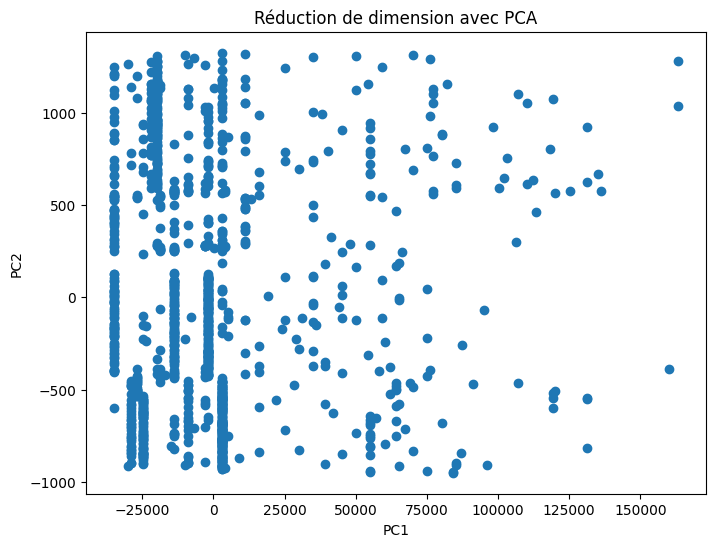

                          mean   median
experience_level                       
Entry             36111.111111  30000.0
Executive         76076.923077  46000.0
Mid               51786.885246  51000.0
Senior            75088.033012  68000.0


In [12]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Charger le dataset
df = pd.read_csv('/content/Data Science Job Salary dataset/datascience_salaries.csv')

# Normalisation Min-Max

scaler = MinMaxScaler()

df['salary_normalized'] = scaler.fit_transform(df[['salary']])


# Réduction de la dimentionnalité avec PCA
df_pca = df.copy()

label_encoder = LabelEncoder()

for col in df_pca.select_dtypes(include='object').columns:
    df_pca[col] = label_encoder.fit_transform(df_pca[col])

pca = PCA(n_components=2)

principal_components = pca.fit_transform(df_pca)

pca_df = pd.DataFrame(
    data=principal_components,
    columns=['PC1', 'PC2']
)

# Visualisation de la reduction de dimentionnalité

plt.figure(figsize=(8,6))

plt.scatter(pca_df['PC1'], pca_df['PC2'])

plt.title("Réduction de dimension avec PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

# Calcul du salaire moyen et du salaire médian

salary_stats = df.groupby('experience_level')['salary'].agg(['mean', 'median'])

print(salary_stats)

In [13]:
!cp /content/drive/MyDrive/'Colab Notebooks'/D.ipynb /content/drive/MyDrive/TTA-Bootcamp-GenAI/Week2/Day2/DailyChallenges

cp: cannot stat 'DailyChallenge.ipynb': No such file or directory
